In [ ]:
from pathlib import Path

import pandas as pd
import yfinance as yf
from tqdm.notebook import tqdm

from stockdata import iSharesSP500, fix_ticker, IndexHistory #, get_constituents

from alpha_vantage.timeseries import TimeSeries

In [2]:
newimd = IndexHistory(iSharesSP500, last_updated=pd.Timestamp(year=2024, month=10, day=31))
newimd.update()
newimd.constituents

100%|██████████| 3/3 [00:02<00:00,  1.42it/s]


2024-11-29    [AAPL, NVDA, MSFT, AMZN, META, GOOGL, TSLA, BR...
2024-12-31    [AAPL, NVDA, MSFT, AMZN, META, TSLA, GOOGL, AV...
2025-01-31    [AAPL, MSFT, NVDA, AMZN, META, GOOGL, TSLA, AV...
Freq: BME, dtype: object

In [ ]:
# Earliest date for which holdings can be retrieved!
#iSharesSP500().get_holdings(pd.Timestamp(year=2006, month=10, day=31))

,Ticker,Name,Sector,Asset Class,Market Value,Weight,Notional Value,Quantity,CUSIP,ISIN,SEDOL,Accrual Date,0,1,2,3,4
0,PMCS,PMC-SIERRA INC.,-,Equity,"{'display': '$1,960,776.09', 'raw': 1960776.09}","{'display': '0.01', 'raw': 0.010976}","{'display': '1,960,776.00', 'raw': 1960776}","{'display': '295,743.00', 'raw': 295743}",69344F106,US69344F1066,2807492,"{'display': '6.63', 'raw': 6.63}",United States,NASDAQ,USD,1.00,-
1,PGL,PEOPLES ENERGY CORPORATION,-,Equity,"{'display': '$2,388,226.47', 'raw': 2388226.47}","{'display': '0.01', 'raw': 0.013369}","{'display': '2,388,226.00', 'raw': 2388226}","{'display': '54,663.00', 'raw': 54663}",711030106,US7110301063,2681403,"{'display': '43.69', 'raw': 43.69}",United States,New York Stock Exchange Inc.,USD,1.00,-
2,ADCT,ADC TELECOMMUNICATIONS,-,Equity,"{'display': '$2,398,999.93', 'raw': 2398999.93}","{'display': '0.01', 'raw': 0.013429}","{'display': '2,399,000.00', 'raw': 2399000}","{'display': '167,645.00', 'raw': 167645}",000886309,US0008863096,B08G9Z7,"{'display': '14.31', 'raw': 14.31}",United States,NASDAQ,USD,1.00,-
3,NAV,NAVISTAR INTERNATIONAL CORP,-,Equity,"{'display': '$2,438,687.12', 'raw': 2438687.12}","{'display': '0.01', 'raw': 0.013652}","{'display': '2,438,687.00', 'raw': 2438687}","{'display': '87,944.00', 'raw': 87944}",63934E108,US63934E1082,2624464,"{'display': '27.73', 'raw': 27.73}",United States,New York Stock Exchange Inc.,USD,1.00,-
4,DDS,DILLARDS INC CLASS A,-,Equity,"{'display': '$2,649,197.53', 'raw': 2649197.53}","{'display': '0.01', 'raw': 0.01483}","{'display': '2,649,198.00', 'raw': 2649198}","{'display': '87,809.00', 'raw': 87809}",254067101,US2540671011,2269768,"{'display': '30.17', 'raw': 30.17}",United States,New York Stock Exchange Inc.,USD,1.00,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,BAC,BANK OF AMERICA CORP,-,Equity,"{'display': '$350,762,276.45', 'raw': 35076227...","{'display': '1.96', 'raw': 1.963549}","{'display': '350,762,276.00', 'raw': 350762276}","{'display': '6,511,273.00', 'raw': 6511273}",060505104,US0605051046,BHZL9B0,"{'display': '53.87', 'raw': 53.87}",United States,SIX Swiss Exchange,USD,1.00,-
497,MSFT,MICROSOFT CORP,-,Equity,"{'display': '$356,753,962.62', 'raw': 35675396...","{'display': '2.00', 'raw': 1.99709}","{'display': '356,753,963.00', 'raw': 356753963}","{'display': '12,426,122.00', 'raw': 12426122}",594918104,US5949181045,2588173,"{'display': '28.71', 'raw': 28.71}",United States,NASDAQ,USD,1.00,-
498,0R01,CITIGROUP INC,-,Equity,"{'display': '$356,775,088.56', 'raw': 35677508...","{'display': '2.00', 'raw': 1.997209}","{'display': '356,775,089.00', 'raw': 356775089}","{'display': '7,112,741.00', 'raw': 7112741}",172967424,US1729674242,B0ZC1L8,"{'display': '50.16', 'raw': 50.16}",United States,London Stock Exchange,USD,1.00,-
499,GEC,GENERAL ELECTRIC,-,Equity,"{'display': '$521,457,757.65', 'raw': 52145775...","{'display': '2.92', 'raw': 2.919094}","{'display': '521,457,758.00', 'raw': 521457758}","{'display': '14,852,115.00', 'raw': 14852115}",369604103,US3696041033,5254471,"{'display': '35.11', 'raw': 35.11}",United States,Deutsche Boerse Xetra,USD,1.00,-


In [7]:
imd = IndexHistory.from_file('./metadata.parquet')
imd.constituents

2019-05-31    [MSFT, AAPL, AMZN, FB, BRKB, JNJ, JPM, GOOG, G...
2019-06-28    [MSFT, AAPL, AMZN, FB, BRKB, JNJ, JPM, GOOG, G...
2019-07-31    [MSFT, AAPL, AMZN, FB, BRKB, JPM, GOOG, GOOGL,...
2019-08-30    [MSFT, AAPL, AMZN, FB, BRKB, GOOG, GOOGL, JPM,...
2019-09-30    [MSFT, AAPL, AMZN, FB, BRKB, JPM, GOOG, GOOGL,...
                                    ...                        
2024-09-30    [AAPL, MSFT, NVDA, AMZN, META, GOOGL, BRKB, GO...
2024-10-31    [AAPL, NVDA, MSFT, AMZN, META, GOOGL, GOOG, BR...
2024-11-29    [AAPL, NVDA, MSFT, AMZN, META, GOOGL, TSLA, BR...
2024-12-31    [AAPL, NVDA, MSFT, AMZN, META, TSLA, GOOGL, AV...
2025-01-31    [AAPL, MSFT, NVDA, AMZN, META, GOOGL, TSLA, AV...
Name: constituents, Length: 69, dtype: object

In [8]:
imd.update()
imd.constituents

0it [00:00, ?it/s]


2019-05-31    [MSFT, AAPL, AMZN, FB, BRKB, JNJ, JPM, GOOG, G...
2019-06-28    [MSFT, AAPL, AMZN, FB, BRKB, JNJ, JPM, GOOG, G...
2019-07-31    [MSFT, AAPL, AMZN, FB, BRKB, JPM, GOOG, GOOGL,...
2019-08-30    [MSFT, AAPL, AMZN, FB, BRKB, GOOG, GOOGL, JPM,...
2019-09-30    [MSFT, AAPL, AMZN, FB, BRKB, JPM, GOOG, GOOGL,...
                                    ...                        
2024-09-30    [AAPL, MSFT, NVDA, AMZN, META, GOOGL, BRKB, GO...
2024-10-31    [AAPL, NVDA, MSFT, AMZN, META, GOOGL, GOOG, BR...
2024-11-29    [AAPL, NVDA, MSFT, AMZN, META, GOOGL, TSLA, BR...
2024-12-31    [AAPL, NVDA, MSFT, AMZN, META, TSLA, GOOGL, AV...
2025-01-31    [AAPL, MSFT, NVDA, AMZN, META, GOOGL, TSLA, AV...
Name: constituents, Length: 69, dtype: object

In [19]:
# Get constituents from 2019-05-29 onwards (end of data series in https://github.com/teddykoker/survivorship-free-spy/tree/master/survivorship-free)
constituents = get_constituents(iSharesSP500, start="20190529")
constituents.to_csv("constituents.csv")
constituents

100%|██████████| 69/69 [00:38<00:00,  1.78it/s]


2019-05-31    [MSFT, AAPL, AMZN, FB, BRKB, JNJ, JPM, GOOG, G...
2019-06-28    [MSFT, AAPL, AMZN, FB, BRKB, JNJ, JPM, GOOG, G...
2019-07-31    [MSFT, AAPL, AMZN, FB, BRKB, JPM, GOOG, GOOGL,...
2019-08-30    [MSFT, AAPL, AMZN, FB, BRKB, GOOG, GOOGL, JPM,...
2019-09-30    [MSFT, AAPL, AMZN, FB, BRKB, JPM, GOOG, GOOGL,...
                                    ...                        
2024-09-30    [AAPL, MSFT, NVDA, AMZN, META, GOOGL, BRKB, GO...
2024-10-31    [AAPL, NVDA, MSFT, AMZN, META, GOOGL, GOOG, BR...
2024-11-29    [AAPL, NVDA, MSFT, AMZN, META, GOOGL, TSLA, BR...
2024-12-31    [AAPL, NVDA, MSFT, AMZN, META, TSLA, GOOGL, AV...
2025-01-31    [AAPL, MSFT, NVDA, AMZN, META, GOOGL, TSLA, AV...
Freq: BME, Length: 69, dtype: object

In [32]:
constituents = pd.read_csv("constituents.csv", index_col=0, converters={1: eval}, parse_dates=True)['0']
constituents

2019-05-31    [MSFT, AAPL, AMZN, FB, BRKB, JNJ, JPM, GOOG, G...
2019-06-28    [MSFT, AAPL, AMZN, FB, BRKB, JNJ, JPM, GOOG, G...
2019-07-31    [MSFT, AAPL, AMZN, FB, BRKB, JPM, GOOG, GOOGL,...
2019-08-30    [MSFT, AAPL, AMZN, FB, BRKB, GOOG, GOOGL, JPM,...
2019-09-30    [MSFT, AAPL, AMZN, FB, BRKB, JPM, GOOG, GOOGL,...
                                    ...                        
2024-09-30    [AAPL, MSFT, NVDA, AMZN, META, GOOGL, BRKB, GO...
2024-10-31    [AAPL, NVDA, MSFT, AMZN, META, GOOGL, GOOG, BR...
2024-11-29    [AAPL, NVDA, MSFT, AMZN, META, GOOGL, TSLA, BR...
2024-12-31    [AAPL, NVDA, MSFT, AMZN, META, TSLA, GOOGL, AV...
2025-01-31    [AAPL, MSFT, NVDA, AMZN, META, GOOGL, TSLA, AV...
Name: 0, Length: 69, dtype: object

In [3]:
tickerfix = {
    "ABC": "COR",
    "BRKB": "BRK-B",
    "ANTM": "ELV",
    #"TWC": "CHTR",
    "PCLN": "BKNG", # https://en.wikipedia.org/wiki/Booking_Holdings
    "HCN": "WELL", # https://en.wikipedia.org/wiki/Welltower
    "MHFI": "SPGI", # https://en.wikipedia.org/wiki/S%26P_Global
    "SLBA": "SLB", # https://en.wikipedia.org/wiki/Schlumberger
    "WAG": "WBA", # https://en.wikipedia.org/wiki/Walgreens
    "KRFT": "KHC", # Merged: https://en.wikipedia.org/wiki/Kraft_Foods
    "TYC": "JCI",    # Merged: https://en.wikipedia.org/wiki/Tyco_International
    "RAI": "BTI", # Merged: https://en.wikipedia.org/wiki/Reynolds_American
    "LTD": "BBWI", # https://en.wikipedia.org/wiki/Bath_%26_Body_Works,_Inc.
    "SNDK": "WDC", # Merged: https://en.wikipedia.org/wiki/SanDisk
    "BRCM": "AVGO", # Merged: https://en.wikipedia.org/wiki/Broadcom
    "DPS": "KDP", # https://en.wikipedia.org/wiki/Keurig_Dr_Pepper
    "LLTC": "ADI", # Merged: https://en.wikipedia.org/wiki/Linear_Technology
    "COH": "TPR", # https://en.wikipedia.org/wiki/Tapestry,_Inc.
    "BCR": "BDX", # Merged: https://en.wikipedia.org/wiki/Bard_(company)
    "CAM": "SLB", # Acquired: https://en.wikipedia.org/wiki/Cameron_International
    #"JOY": "", # Acquired: https://en.wikipedia.org/wiki/Joy_Global
    "MJN": "RKT", # Merger: https://en.wikipedia.org/wiki/Mead_Johnson
    #"ARG": "" # https://en.wikipedia.org/wiki/Airgas
    "CFN": "BDX", # Acquired: https://en.wikipedia.org/wiki/CareFusion
    "TSO": "MPC", # Acquired: https://en.wikipedia.org/wiki/Tesoro_Corporation
    "MWV": "SW", # Merged: https://en.wikipedia.org/wiki/MeadWestvaco, merged: https://en.wikipedia.org/wiki/WestRock
    "WFM": "AMZN", # Acquired: https://en.wikipedia.org/wiki/Whole_Foods_Market
    "LO": "BATS", # Acquired: https://en.wikipedia.org/wiki/Lorillard_Tobacco_Company
    "SPLS": "SPLS", # Acquired and taken private: https://en.wikipedia.org/wiki/Staples_Inc.
    "HSP": "PFE", # Acquired by Pfizer: https://en.wikipedia.org/wiki/Hospira
    "STJ": "ABT", # Acquired by Abbott Laboratories: https://en.wikipedia.org/wiki/St._Jude_Medical
    "TE": "EMA", # Acquired by Emera : https://en.wikipedia.org/wiki/TECO_Energy
    "CVC": "ATUS", # Acquired by Altice: https://en.wikipedia.org/wiki/Cablevision
    "PCS": "TMUS", # Merged with T-Mobile: https://en.wikipedia.org/wiki/Metro_by_T-Mobile
    "APOL": "APOL", # Acquired and taken private: https://en.wikipedia.org/wiki/Apollo_Education_Group
    "SIAL": "MRK", # Acquired by Merck Group: https://en.wikipedia.org/wiki/Sigma-Aldrich
    "NYX": "ICE", # Merged with Euronext NV and acquired by Intercontinental Exchange: https://en.wikipedia.org/wiki/NYSE_Euronext
    "FDO": "DLTR", # Acquired by Dollar Tree: https://en.wikipedia.org/wiki/Dollar_Tree
    "LUK": "JEF", # https://en.wikipedia.org/wiki/Jefferies_Financial_Group
    "SWY": "ACI", # Acquired by Albertsons: https://en.wikipedia.org/wiki/Safeway
    "HCBK": "MTB", # Acquired by M&T Bank: https://en.wikipedia.org/wiki/Hudson_City_Bancorp
    "GEC": "GE", # Split in 3 entities; trading name changed to GE Aerospace: https://en.wikipedia.org/wiki/General_Electric
    "VISA": "V", # https://en.wikipedia.org/wiki/Visa_Inc.
    "UTX": "RTX", # Merged with United Technologies Corporation (UTC): https://en.wikipedia.org/wiki/RTX_Corporation
    "FB": "META", # Renamed to META
    "DWDP": "DD", # Merged and split in 3: https://en.wikipedia.org/wiki/DuPont
    "RTN": "RTX", # Merged with United Technologies Corporation (UTC): https://en.wikipedia.org/wiki/Raytheon
    "BBT": "TFC", # Merged with SunTrust Banks: https://en.wikipedia.org/wiki/Bb_And_T_Corp
    "RHT": "IBM", # Acquired by IBM: https://en.wikipedia.org/wiki/Red_Hat_Inc
    "ATVI": "MSFT", # Acquired by Microsoft: https://en.wikipedia.org/wiki/Activision_Blizzard_Inc
    "XLNX": "AMD", # Acquired by AMD: https://en.wikipedia.org/wiki/Xilinx_Inc
    "ALXN": "AZN", # Acquired by AstraZeneca: https://en.wikipedia.org/wiki/Alexion_Pharmaceuticals_Inc
    "CERN": "ORCL", # Acquired by Oracle: https://en.wikipedia.org/wiki/Cerner_Corp
    "WLTW": "WTW", # Renamed ticker
    "HRS": "LHX", # Merged with L3 Technologies: https://en.wikipedia.org/wiki/Harris_Corp
    "LLL": "LHX", # Merged with Harris Corporation: https://en.wikipedia.org/wiki/L3_Technologies
    "BLL": "BALL", # Renamed ticker
    "TSS": "GPN", # Merged with Global Payments Inc.: https://en.wikipedia.org/wiki/TSYS
    "CXO": "COP", # Acquired by ConocoPhillips: https://en.wikipedia.org/wiki/Concho_Resources
    "CELG": "BMY", # Acquired by Bristol-Myers Squibb: https://en.wikipedia.org/wiki/Celgene
    "AGN": "ABBV", # Acquired by AbbVie: https://en.wikipedia.org/wiki/Allergan
    "APC": "OXY", # Acquired by Occidental Petroleum: https://en.wikipedia.org/wiki/Anadarko_Petroleum
    "CBS": "PARA", # Merged with Viacom and renamed to Paramount Global: https://en.wikipedia.org/wiki/CBS_Corporation
    "VIAB": "PARA", # Merged with CBS and renamed to Paramount Global: https://en.wikipedia.org/wiki/Viacom_(2005%E2%80%932019)
    #"FRC": "", # Sold to JPMorgan Chase: https://en.wikipedia.org/wiki/First_Republic_Bank
    "MXIM": "ADI", # Acquired by Analog Devices: https://en.wikipedia.org/wiki/Maxim_Integrated
    "WCG": "CNC", # Acquired by Centene Corporation: https://en.wikipedia.org/wiki/WellCare
    "SYMC": "GEN", # Merged with Avast and renamed Gen Digital: https://en.wikipedia.org/wiki/Gen_Digital
    "ABMD": "JNJ", # Acquired by Johnson & Johnson: https://en.wikipedia.org/wiki/Abiomed
    #"CTXS": "", # Acquired by private investors and merged to form Cloud Software Group: https://en.wikipedia.org/wiki/Citrix_Systems
    #"VAR": "SHL", # Acquired by Siemens Healthineers (listed on DAX): https://en.wikipedia.org/wiki/Varian_Medical_Systems
    "KSU": "CP", # Acquired by and merged into Canadian Pacific Kansas City: https://en.wikipedia.org/wiki/Kansas_City_Southern_(company)
    "ETFC": "MS", # Acquired by Morgan Stanley: https://en.wikipedia.org/wiki/E-Trade
    "BHGE": "BKR", # Renamed ticker: https://en.wikipedia.org/wiki/Baker_Hughes
    "DRE": "PLD", # Acquired by Prologis: https://en.wikipedia.org/wiki/Duke_Realty
    #"SIVB": "", # Broken up: https://en.wikipedia.org/wiki/SVB_Financial_Group
    "COG": "CTRA", # Renamed to Coterra Energy: https://en.wikipedia.org/wiki/Coterra
    "XEC": "CTRA", # Acquired by Cabot Oil & Gas to form Coterra Energy: https://en.wikipedia.org/wiki/Cimarex_Energy
    "NBL": "CVX", # Acquired by Chevron Corporation: https://en.wikipedia.org/wiki/Noble_Energy
    "RE": "EG", # Renamed ticker: https://en.wikipedia.org/wiki/Everest_Group
    "CTL": "LUMN", # Rebranded and renamed ticker: https://en.wikipedia.org/wiki/Lumen_Technologies#2020_name_change_to_Lumen
    #"TIF": "MC", # Acquired by LVMH Moët Hennessy Louis Vuitton SE (MC on Euronext Paris): https://en.wikipedia.org/wiki/Tiffany_%26_Co.
    #"PKI": "", # Split and relevant part taken private: https://en.wikipedia.org/wiki/PerkinElmer
    "DISCK": "WBD", # Merged with WarnerMedia forming Warner Bros. Discovery: https://en.wikipedia.org/wiki/Discovery,_Inc.
    "DISCA": "WBD", # Merged with WarnerMedia forming Warner Bros. Discovery: https://en.wikipedia.org/wiki/Discovery,_Inc.
    "TMK": "GL", # Renamed to Globe Life: https://en.wikipedia.org/wiki/Globe_Life
    "ARNC": "HWM", # Renamed to Howmet Aerospace Inc.: https://en.wikipedia.org/wiki/Howmet_Aerospace
    "MYL": "VTRS", # Merged with Upjohn (Pfizer) to form Viatris: https://en.wikipedia.org/wiki/Mylan
    "JEC": "J", # Rebranded to Jacobs Solutions Inc. and renamed ticker : https://en.wikipedia.org/wiki/Jacobs_Solutions
    #"NLSN": "", # Taken private: https://en.wikipedia.org/wiki/Nielsen_Holdings
    "FBHS": "FBIN", # Rebranded to Fortune Brands Innovations Inc.: https://en.wikipedia.org/wiki/Fortune_Brands_Innovations
    "FLIR": "TDY", # Acquired by Teledyne Technologies: https://en.wikipedia.org/wiki/Teledyne_FLIR
    "ADS": "BFH", # Rebranded to Bread Financial: https://en.wikipedia.org/wiki/Bread_Financial
    "PBCT": "MTB", # Merged with M&T Bank: https://en.wikipedia.org/wiki/People%27s_United_Financial
    "HFC": "DINO", # Rebranded to HF Sinclair Corporation: https://en.wikipedia.org/wiki/HF_Sinclair
    "GPS": "GAP", # Renamed ticker: https://en.wikipedia.org/wiki/Gap_Inc.
    "PXD": "XOM", # Acquired by ExxonMobil: https://en.wikipedia.org/wiki/Pioneer_Natural_Resources
    "FLT": "CPAY", # Rebranded to Corpay Inc. and renamed ticker: https://en.wikipedia.org/wiki/Corpay
    "WRK": "SW", # Merged with Smurfit Kappa to become Smurfit Westrock: https://en.wikipedia.org/wiki/WestRock
    "DISH": "SATS", # Merged into EchoStar Corporation: https://en.wikipedia.org/wiki/Dish_Network
    "FISV": "FI", # Renamed ticker: https://en.wikipedia.org/wiki/Fiserv
    "STI": "TFC", # Acquired by BB&T Corporation to form Truist Financial Corporation: https://en.wikipedia.org/wiki/SunTrust_Banks#Truist_Financial_Corporation
    "INFO": "SPGI", # Merged with S&P Global: https://en.wikipedia.org/wiki/IHS_Markit
    "HCP": "DOC", # Rebranded to Healthpeak Properties, Inc. and renamed ticker: https://en.wikipedia.org/wiki/Healthpeak_Properties
    "LB": "BBWI", # Renamed to Bath & Body Works, Inc.: https://en.wikipedia.org/wiki/Bath_%26_Body_Works,_Inc.
}

In [16]:
stockdata = {}
skips = set()
startdate = constituents.index[0]
fixconstituents = list(set([fix_ticker(el, replacedict=tickerfix) for el in constituents.explode().unique()]))
for companyticker in tqdm(fixconstituents):
    df = yf.Ticker(companyticker).history(start=startdate)
    if df.empty:
        skips.add(companyticker)
    else:
        stockdata[companyticker] = df
stockdata

  0%|          | 0/595 [00:00<?, ?it/s]

100%|██████████| 595/595 [02:00<00:00,  4.93it/s]


{'KKR':                                  Open        High         Low       Close  \
 Date                                                                        
 2019-05-31 00:00:00-04:00   21.536620   21.536620   20.852770   20.871506   
 2019-06-03 00:00:00-04:00   20.777834   21.302431   20.618581   21.283695   
 2019-06-04 00:00:00-04:00   21.649037   22.089324   21.442944   22.079956   
 2019-06-05 00:00:00-04:00   22.220473   22.304784   21.836393   22.211105   
 2019-06-06 00:00:00-04:00   22.183004   22.398464   22.154900   22.286051   
 ...                               ...         ...         ...         ...   
 2025-02-10 00:00:00-05:00  149.911443  151.209798  146.375882  147.744156   
 2025-02-11 00:00:00-05:00  145.926445  146.685485  141.701763  142.281036   
 2025-02-12 00:00:00-05:00  140.443330  140.842837  138.226118  139.364685   
 2025-02-13 00:00:00-05:00  140.792900  141.272293  137.666827  139.125000   
 2025-02-14 00:00:00-05:00  139.610001  141.789993  138.5

In [87]:
skips.remove('TIF')
skips.remove('TWTR')

In [ ]:
stockdata = {}

# Timezone info used by Yahoo data.
data_tz = pd.read_parquet(f"./data/AAPL.parquet", columns=[]).index.tz

# Free API key allows 25 requests per day
ts = TimeSeries(key='X8469DEGTZCRVF6J', output_format='pandas')
skipremove = set()
for company in skips:
    try:
        # Get json object with the intraday data and another with  the call's metadata
        data, meta_data = ts.get_daily(symbol=company, outputsize='full')
        data.index = data.index.tz_localize(data_tz)
        data = data.rename(columns={'1. open': 'Open', '2. high': 'High', '3. low': 'Low', '4. close': 'Close', '5. volume': 'Volume'}).sort_index()
        stockdata[company] = data
        skipremove.add(company)
    except:
        continue
skips = skips - skipremove
#data.to_parquet(f"./data/{meta_data['2. Symbol']}.parquet")

In [98]:
# Export to parquet files
pd.DataFrame(list(skips), columns=["Skips"]).to_parquet("./data/skips.parquet")
for k, v in stockdata.items():
    v.to_parquet(f"./data/{k}.parquet")

In [83]:
skips = set(pd.read_parquet("./data/skips.parquet")["Skips"].to_list())
sp500approx = pd.Series(data=pd.NA, index=constituents.index)
data_tz = pd.read_parquet(f"./data/AAPL.parquet", columns=[]).index.tz
for curdate, curcompanies in tqdm(constituents.items()):
    #curcompanies = list(set([fix_ticker(el, replacedict=tickerfix) for el in curcompanies]))
    curdate = curdate.tz_localize(data_tz)
    curcompanies = filter(lambda company: Path(f"./data/{company}.parquet").exists(), curcompanies)
    curavg = pd.concat([pd.read_parquet(f"./data/{company}.parquet", columns=["Close"])[curdate:(curdate + pd.offsets.Hour(n=24) - pd.offsets.Minute(n=1))] for company in curcompanies], axis=1).mean(axis=1) #if company not in skips
    sp500approx.loc[curdate.tz_localize(None)] = curavg.values[0] if not curavg.empty else pd.NA
sp500approx

0it [00:00, ?it/s]

2019-05-31     90.477872
2019-06-28     97.790652
2019-07-31     98.543908
2019-08-30     97.712579
2019-09-30    107.466242
                 ...    
2024-09-30    219.536084
2024-10-31    214.650648
2024-11-29    230.347855
2024-12-31    216.538838
2025-01-31     224.02276
Length: 69, dtype: object

[*********************100%***********************]  1 of 1 completed


<Axes: >

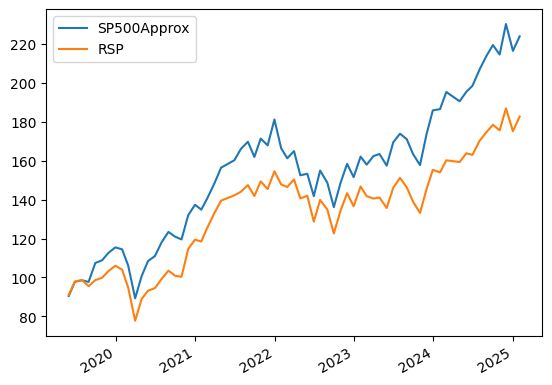

In [84]:
# Compare to equal weight S&P 500 ETF RSP
rsp_df = yf.Tickers("RSP").download(start=sp500approx.index.min(), end=sp500approx.index.max())['Close'].resample("BME").last()
# Compare both by plotting
pd.concat([sp500approx.to_frame("SP500Approx"), rsp_df], axis=1).dropna(how='any', axis=0).plot()